# Setup

In [1]:
"""02_baselines.ipynb — Splits, propensity, S-learner, T-learner.

We start with the plumbing (splits + propensity) and then train the two
simplest meta-learners. The point isn't to crown a winner; it's to
demonstrate the structural failure modes of each, which motivates the
more sophisticated estimators in Phase 3.
"""

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from uplift.data import load_raw
from uplift.splits import make_splits, save_splits, load_splits
from uplift.treatment import (
    FEATURE_COLS,
    get_features,
    make_binary_treatment,
    make_xty,
    naive_ate,
)
from uplift.propensity import (
    PropensityModel,
    estimate_propensity_cv,
    overlap_diagnostics,
)

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 150
plt.rcParams["savefig.bbox"] = "tight"

RNG = np.random.default_rng(42)

# Create and save the splits

In [2]:
df = load_raw()
splits = make_splits(df, seed=42)
save_splits(splits)

for name, sdf in splits.items():
    T = make_binary_treatment(sdf)
    print(f"{name:6s}  n={len(sdf):>6,}  treated_rate={T.mean():.4f}")

train   n=38,400  treated_rate=0.6671
val     n=12,800  treated_rate=0.6671
test    n=12,800  treated_rate=0.6671


# Verify naive ATEs are preserved across splits

In [3]:
print(f"{'split':6s}  {'visit ATE':>10s}  {'visit SE':>10s}  {'spend ATE':>10s}  {'spend SE':>10s}")
for name, sdf in splits.items():
    v = naive_ate(sdf, "visit")
    s = naive_ate(sdf, "spend")
    print(
        f"{name:6s}  "
        f"{v['ate']:>+10.4f}  {v['ate_se']:>10.4f}  "
        f"{s['ate']:>+10.4f}  {s['ate_se']:>10.4f}"
    )

split    visit ATE    visit SE   spend ATE    spend SE
train      +0.0634      0.0036     +0.4975      0.1476
val        +0.0519      0.0063     +0.8729      0.2552
test       +0.0622      0.0061     +0.6186      0.2357


# Fit the propensity model on train

In [4]:
train_df = splits["train"]
X_train = get_features(train_df)
T_train = make_binary_treatment(train_df)

propensity = PropensityModel().fit(X_train, T_train)

# In-sample predictions on train (for diagnostic plotting only — don't
# use these for downstream IPS, that requires out-of-fold).
p_train_in = propensity.predict(X_train)
print("In-sample propensity diagnostics:")
for k, v in overlap_diagnostics(p_train_in).items():
    print(f"  {k:25s} {v:.4f}")

In-sample propensity diagnostics:
  min                       0.4204
  max                       0.8604
  mean                      0.6671
  std                       0.0408
  frac_extreme              0.0000
  frac_in_unit_interval     1.0000


# Out-of-fold propensity for downstream use

In [5]:
p_train_oof = estimate_propensity_cv(X_train, T_train, n_splits=5)
print("Out-of-fold propensity diagnostics:")
for k, v in overlap_diagnostics(p_train_oof).items():
    print(f"  {k:25s} {v:.4f}")

# Save for Phase 4 (IPS, DR-learner)
np.save(PROJECT_ROOT / "data" / "processed" / "propensity_train_oof.npy", p_train_oof)

Out-of-fold propensity diagnostics:
  min                       0.4136
  max                       0.8861
  mean                      0.6668
  std                       0.0456
  frac_extreme              0.0000
  frac_in_unit_interval     1.0000


# Plot the propensity distribution

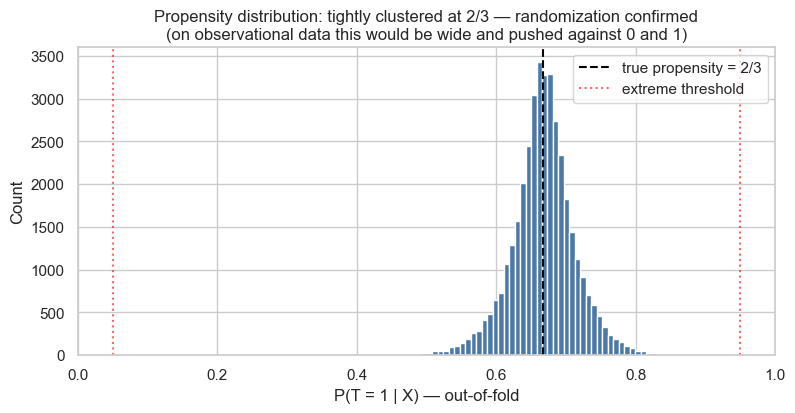

In [6]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(p_train_oof, bins=60, color="#4c78a8", edgecolor="white")
ax.axvline(2 / 3, color="black", linestyle="--", label="true propensity = 2/3")
ax.axvline(0.05, color="red", linestyle=":", alpha=0.6, label="extreme threshold")
ax.axvline(0.95, color="red", linestyle=":", alpha=0.6)
ax.set_xlabel("P(T = 1 | X) — out-of-fold")
ax.set_ylabel("Count")
ax.set_xlim(0, 1)
ax.set_title(
    "Propensity distribution: tightly clustered at 2/3 — randomization confirmed\n"
    "(on observational data this would be wide and pushed against 0 and 1)"
)
ax.legend(loc="upper right")
fig.savefig(FIG_DIR / "06_propensity_distribution.png")
plt.show()

# Cross-check: AUC and Feature Importance

In [7]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(T_train, p_train_oof)
print(f"Propensity model AUC: {auc:.4f}")
print(f"  (≈ 0.50 ⇒ treatment is unpredictable ⇒ randomization holds)\n")

importances = pd.Series(
    propensity.model.feature_importances_,
    index=propensity.feature_cols_,
).sort_values(ascending=False)
print("Top 10 'most predictive' features for treatment:")
print(importances.head(10))
print("\nNote: these are noise. Under randomization, NO feature should be")
print("meaningfully predictive of treatment. The model is fitting tiny")
print("residual fluctuations.")

Propensity model AUC: 0.5021
  (≈ 0.50 ⇒ treatment is unpredictable ⇒ randomization holds)

Top 10 'most predictive' features for treatment:
history                      2747
recency                      1256
mens                          357
channel_Phone                 326
zip_code_Surburban            311
zip_code_Urban                311
newbie                        301
channel_Web                   179
womens                        168
history_segment_3_200_350      11
dtype: int32

Note: these are noise. Under randomization, NO feature should be
meaningfully predictive of treatment. The model is fitting tiny
residual fluctuations.


# Imports and train both learners

In [8]:
from uplift.learners import SLearner, TLearner

# Convenience accessors for the val split
val_df = splits["val"]
X_train_feat = get_features(train_df)
T_train_bin = make_binary_treatment(train_df)
Y_train_visit = train_df["visit"]

X_val_feat = get_features(val_df)
T_val_bin = make_binary_treatment(val_df)
Y_val_visit = val_df["visit"]

print("Training S-learner...")
slearner = SLearner().fit(X_train_feat, T_train_bin, Y_train_visit)
print("Training T-learner...")
tlearner = TLearner().fit(X_train_feat, T_train_bin, Y_train_visit)
print("Done.")

cate_s_val = slearner.predict_cate(X_val_feat)
cate_t_val = tlearner.predict_cate(X_val_feat)

Training S-learner...
Training T-learner...
Done.


# Compare mean CATE to the naive ATE (sanity floor)

In [9]:
naive_val = naive_ate(val_df, "visit")["ate"]

print(f"{'Method':<20s}  {'mean CATE':>10s}  {'std CATE':>10s}  {'mean/naive':>12s}")
print("-" * 60)
print(f"{'Naive ATE':<20s}  {naive_val:>+10.4f}  {'':>10s}  {1.0:>12.3f}")
print(
    f"{'S-learner':<20s}  {cate_s_val.mean():>+10.4f}  {cate_s_val.std():>10.4f}  {cate_s_val.mean() / naive_val:>12.3f}"
)
print(
    f"{'T-learner':<20s}  {cate_t_val.mean():>+10.4f}  {cate_t_val.std():>10.4f}  {cate_t_val.mean() / naive_val:>12.3f}"
)

Method                 mean CATE    std CATE    mean/naive
------------------------------------------------------------
Naive ATE                +0.0519                     1.000
S-learner                +0.0622      0.0368         1.199
T-learner                +0.0639      0.0674         1.231


# Visual: CATE distributions side by side

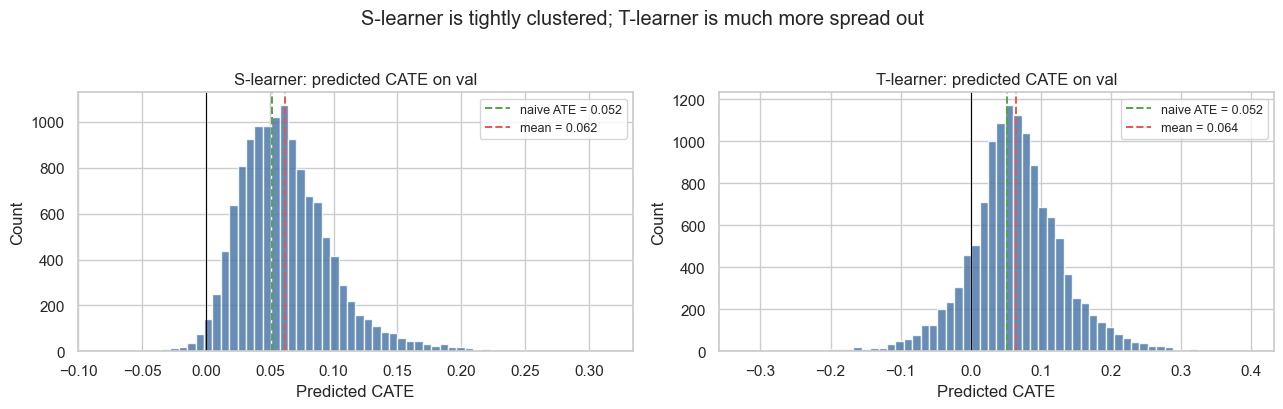

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, cate, name in zip(axes, [cate_s_val, cate_t_val], ["S-learner", "T-learner"]):
    ax.hist(cate, bins=60, color="#4c78a8", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(
        naive_val,
        color="#54a24b",
        linestyle="--",
        linewidth=1.4,
        label=f"naive ATE = {naive_val:.3f}",
    )
    ax.axvline(
        cate.mean(),
        color="#e45756",
        linestyle="--",
        linewidth=1.4,
        label=f"mean = {cate.mean():.3f}",
    )
    ax.set_title(f"{name}: predicted CATE on val")
    ax.set_xlabel("Predicted CATE")
    ax.set_ylabel("Count")
    ax.legend(loc="upper right", fontsize=9)

fig.suptitle("S-learner is tightly clustered; T-learner is much more spread out", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_cate_distributions.png")
plt.show()

# Demonstrating S-learner shrinkage with deliberate over-regularization

In [11]:
# Heavily regularized S-learner — small trees, few of them, large leaves
slearner_strong = SLearner(
    base_params={
        "n_estimators": 50,
        "max_depth": 3,
        "num_leaves": 7,
        "min_child_samples": 500,
    }
).fit(X_train_feat, T_train_bin, Y_train_visit)

cate_s_strong = slearner_strong.predict_cate(X_val_feat)

print("S-learner: effect of regularization on the CATE distribution\n")
print(f"{'Config':<20s}  {'mean CATE':>10s}  {'std CATE':>10s}  {'shrinkage':>12s}")
print("-" * 60)
print(
    f"{'Default (n=200)':<20s}  {cate_s_val.mean():>+10.4f}  {cate_s_val.std():>10.4f}  {cate_s_val.mean() / naive_val:>11.1%}"
)
print(
    f"{'Heavy reg (n=50)':<20s}  {cate_s_strong.mean():>+10.4f}  {cate_s_strong.std():>10.4f}  {cate_s_strong.mean() / naive_val:>11.1%}"
)
print(f"{'Naive ATE':<20s}  {naive_val:>+10.4f}  {'—':>10s}  {1.0:>11.1%}")
print()
print("The heavily regularized model has a smaller mean CATE — the treatment")
print("feature is competing for limited model capacity against other features,")
print("and regularization can effectively zero out its contribution.")
print()
print("This is the structural reason S-learner can be biased toward zero.")

S-learner: effect of regularization on the CATE distribution

Config                 mean CATE    std CATE     shrinkage
------------------------------------------------------------
Default (n=200)          +0.0622      0.0368       119.9%
Heavy reg (n=50)         +0.0486      0.0216        93.7%
Naive ATE                +0.0519           —       100.0%

The heavily regularized model has a smaller mean CATE — the treatment
feature is competing for limited model capacity against other features,
and regularization can effectively zero out its contribution.

This is the structural reason S-learner can be biased toward zero.


# Demonstrating T-learner variance using per-arm sample sizes

In [12]:
n_treated = (T_train_bin == 1).sum()
n_control = (T_train_bin == 0).sum()
print(f"Training data per arm:")
print(f"  μ_1 trained on {n_treated:>6,} samples (treated)")
print(f"  μ_0 trained on {n_control:>6,} samples (control)")
print(f"  Ratio: {n_treated / n_control:.2f}x more data for the treated model\n")

# Compare prediction "confidence" by looking at the spread of CATE predictions
# between the two methods. T-learner's wider distribution = it's making
# stronger per-customer claims, some of which are noise.
extreme_cates_s = ((cate_s_val < -0.05) | (cate_s_val > 0.20)).mean()
extreme_cates_t = ((cate_t_val < -0.05) | (cate_t_val > 0.20)).mean()
print(f"Fraction of CATEs outside [-0.05, +0.20]:")
print(f"  S-learner: {extreme_cates_s:.1%}")
print(f"  T-learner: {extreme_cates_t:.1%}")
print()
print("T-learner is much more willing to predict 'this customer has a")
print("strongly negative or strongly positive treatment effect'. Some of")
print("those claims are real (true heterogeneity) and some are noise from")
print("the control-arm model fitting random patterns in less data.")

Training data per arm:
  μ_1 trained on 25,616 samples (treated)
  μ_0 trained on 12,784 samples (control)
  Ratio: 2.00x more data for the treated model

Fraction of CATEs outside [-0.05, +0.20]:
  S-learner: 0.5%
  T-learner: 7.3%

T-learner is much more willing to predict 'this customer has a
strongly negative or strongly positive treatment effect'. Some of
those claims are real (true heterogeneity) and some are noise from
the control-arm model fitting random patterns in less data.


# Rank agreement between S and T

In [13]:
from scipy.stats import kendalltau, spearmanr

tau, _ = kendalltau(cate_s_val, cate_t_val)
rho, _ = spearmanr(cate_s_val, cate_t_val)

print(f"Rank agreement between S-learner and T-learner on val set:")
print(f"  Kendall's τ: {tau:.3f}")
print(f"  Spearman ρ:  {rho:.3f}")
print()
if tau < 0.5:
    print("⚠️  Low agreement: the two methods rank customers very differently.")
    print("    Policy choice depends heavily on which method we trust.")
else:
    print("Reasonable agreement on the ranking — both methods see similar")
    print("structure, even if magnitudes differ. The cross-check is encouraging:")
    print("the heterogeneity signal is robust to method choice.")

Rank agreement between S-learner and T-learner on val set:
  Kendall's τ: 0.554
  Spearman ρ:  0.737

Reasonable agreement on the ranking — both methods see similar
structure, even if magnitudes differ. The cross-check is encouraging:
the heterogeneity signal is robust to method choice.


# Sanity check: top-decile realized lift

In [14]:
def realized_lift_in_top_k(
    df_eval: pd.DataFrame, cate_pred: np.ndarray, k: float, outcome: str = "visit"
) -> float:
    """Realized treatment effect among the top-k fraction by predicted CATE."""
    n_top = int(len(df_eval) * k)
    top_idx = np.argsort(-cate_pred)[:n_top]
    top = df_eval.iloc[top_idx]
    T_top = make_binary_treatment(top)
    Y_top = top[outcome]
    if T_top.sum() < 10 or (T_top == 0).sum() < 10:
        return np.nan
    return Y_top[T_top == 1].mean() - Y_top[T_top == 0].mean()


print(f"Realized lift on val by decile of predicted CATE (visit outcome):\n")
print(f"{'Method':<12s}  {'top 10%':>10s}  {'top 30%':>10s}  {'bottom 10%':>12s}  {'overall':>10s}")
print("-" * 65)
for name, cate in [("S-learner", cate_s_val), ("T-learner", cate_t_val)]:
    t10 = realized_lift_in_top_k(val_df, cate, 0.10)
    t30 = realized_lift_in_top_k(val_df, cate, 0.30)
    b10 = realized_lift_in_top_k(val_df, -cate, 0.10)  # bottom = top of negated
    print(f"{name:<12s}  {t10:>+10.4f}  {t30:>+10.4f}  {b10:>+12.4f}  {naive_val:>+10.4f}")

Realized lift on val by decile of predicted CATE (visit outcome):

Method           top 10%     top 30%    bottom 10%     overall
-----------------------------------------------------------------
S-learner        +0.0912     +0.0719       +0.0789     +0.0519
T-learner        +0.0749     +0.0651       +0.1137     +0.0519


# Save CATEs for downstream evaluation

In [15]:
test_df = splits["test"]
X_test_feat = get_features(test_df)

cate_s_test = slearner.predict_cate(X_test_feat)
cate_t_test = tlearner.predict_cate(X_test_feat)

cate_dir = PROJECT_ROOT / "data" / "processed"
pd.DataFrame(
    {"slearner_visit": cate_s_val, "tlearner_visit": cate_t_val},
    index=val_df.index,
).to_parquet(cate_dir / "cate_val.parquet")

pd.DataFrame(
    {"slearner_visit": cate_s_test, "tlearner_visit": cate_t_test},
    index=test_df.index,
).to_parquet(cate_dir / "cate_test.parquet")

print(f"Saved CATE predictions to {cate_dir / 'cate_*.parquet'}")
print(f"  val:  {len(cate_s_val):,} rows × 2 methods")
print(f"  test: {len(cate_s_test):,} rows × 2 methods")

Saved CATE predictions to c:\Users\User\Desktop\portfolio_projects\ML_projects\uplift-promotions\data\processed\cate_*.parquet
  val:  12,800 rows × 2 methods
  test: 12,800 rows × 2 methods


# Train X-learner

In [ ]:
from src.uplift.learners import XLearner

print("Training X-learner...")
xlearner = XLearner(propensity_model=propensity).fit(X_train_feat, T_train_bin, Y_train_visit)
print("Done.")

cate_x_val = xlearner.predict_cate(X_val_feat)
cate_x_test = xlearner.predict_cate(X_test_feat)

Training X-learner...
Done.


# Side-by-side comparison of all three meta-learners

In [18]:
print(f"{'Method':<12s}  {'mean CATE':>10s}  {'std CATE':>10s}  {'mean/naive':>12s}")
print("-" * 52)
print(f"{'Naive ATE':<12s}  {naive_val:>+10.4f}  {'—':>10s}  {1.0:>12.3f}")
print(
    f"{'S-learner':<12s}  {cate_s_val.mean():>+10.4f}  {cate_s_val.std():>10.4f}  {cate_s_val.mean() / naive_val:>12.3f}"
)
print(
    f"{'T-learner':<12s}  {cate_t_val.mean():>+10.4f}  {cate_t_val.std():>10.4f}  {cate_t_val.mean() / naive_val:>12.3f}"
)
print(
    f"{'X-learner':<12s}  {cate_x_val.mean():>+10.4f}  {cate_x_val.std():>10.4f}  {cate_x_val.mean() / naive_val:>12.3f}"
)

Method         mean CATE    std CATE    mean/naive
----------------------------------------------------
Naive ATE        +0.0519           —         1.000
S-learner        +0.0622      0.0368         1.199
T-learner        +0.0639      0.0674         1.231
X-learner        +0.0634      0.0490         1.222


# Three-way distribution comparison

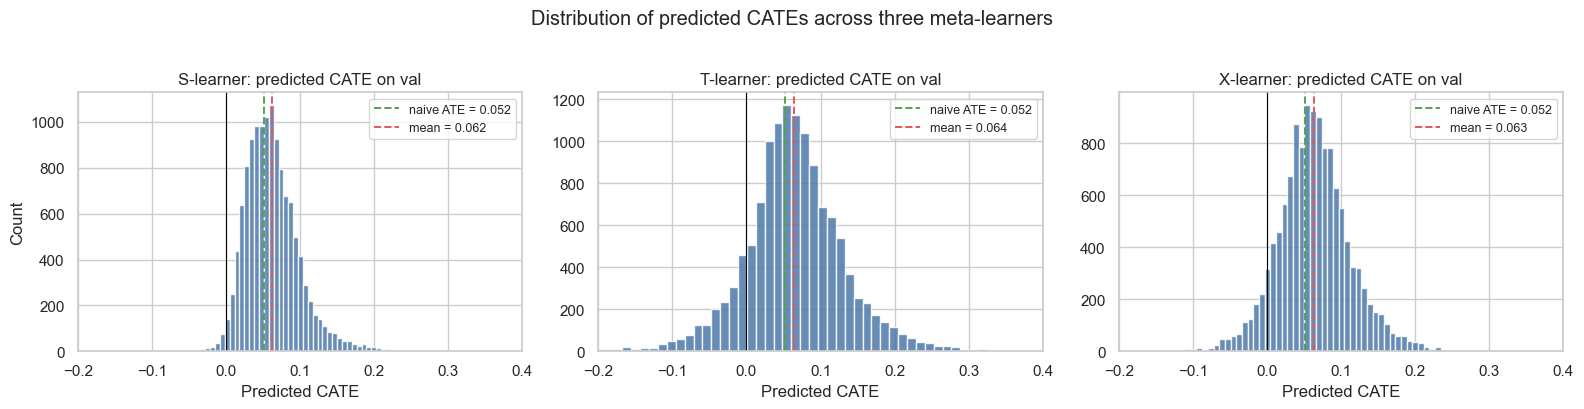

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, cate, name in zip(
    axes,
    [cate_s_val, cate_t_val, cate_x_val],
    ["S-learner", "T-learner", "X-learner"],
):
    ax.hist(cate, bins=60, color="#4c78a8", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.axvline(
        naive_val,
        color="#54a24b",
        linestyle="--",
        linewidth=1.4,
        label=f"naive ATE = {naive_val:.3f}",
    )
    ax.axvline(
        cate.mean(),
        color="#e45756",
        linestyle="--",
        linewidth=1.4,
        label=f"mean = {cate.mean():.3f}",
    )
    ax.set_title(f"{name}: predicted CATE on val")
    ax.set_xlabel("Predicted CATE")
    ax.set_xlim(-0.2, 0.4)  # same x-range across panels for fair comparison
    ax.legend(loc="upper right", fontsize=9)

axes[0].set_ylabel("Count")
fig.suptitle("Distribution of predicted CATEs across three meta-learners", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "08_three_meta_learners.png")
plt.show()

# Rank agreement across all three

In [20]:
from scipy.stats import kendalltau
import itertools

methods = {
    "S-learner": cate_s_val,
    "T-learner": cate_t_val,
    "X-learner": cate_x_val,
}

print("Pairwise Kendall's τ between methods:")
print(f"{'':12s}  {'S':>8s}  {'T':>8s}  {'X':>8s}")
print("-" * 42)
for name_a, cate_a in methods.items():
    row = f"{name_a:<12s}  "
    for name_b, cate_b in methods.items():
        tau, _ = kendalltau(cate_a, cate_b)
        row += f"{tau:>8.3f}  "
    print(row)

Pairwise Kendall's τ between methods:
                     S         T         X
------------------------------------------
S-learner        1.000     0.554     0.526  
T-learner        0.554     1.000     0.634  
X-learner        0.526     0.634     1.000  


# Update the saved CATE files to include X-learner

In [21]:
pd.DataFrame(
    {"slearner_visit": cate_s_val, "tlearner_visit": cate_t_val, "xlearner_visit": cate_x_val},
    index=val_df.index,
).to_parquet(PROJECT_ROOT / "data" / "processed" / "cate_val.parquet")

pd.DataFrame(
    {"slearner_visit": cate_s_test, "tlearner_visit": cate_t_test, "xlearner_visit": cate_x_test},
    index=test_df.index,
).to_parquet(PROJECT_ROOT / "data" / "processed" / "cate_test.parquet")

print("Updated cate_val.parquet and cate_test.parquet with X-learner predictions.")

Updated cate_val.parquet and cate_test.parquet with X-learner predictions.


# Realized top-decile lift across all three

In [22]:
print("Realized lift on val by decile (visit outcome):\n")
print(f"{'Method':<12s}  {'top 10%':>10s}  {'top 30%':>10s}  {'bottom 10%':>12s}  {'overall':>10s}")
print("-" * 65)
for name, cate in methods.items():
    t10 = realized_lift_in_top_k(val_df, cate, 0.10)
    t30 = realized_lift_in_top_k(val_df, cate, 0.30)
    b10 = realized_lift_in_top_k(val_df, -cate, 0.10)
    print(f"{name:<12s}  {t10:>+10.4f}  {t30:>+10.4f}  {b10:>+12.4f}  {naive_val:>+10.4f}")

Realized lift on val by decile (visit outcome):

Method           top 10%     top 30%    bottom 10%     overall
-----------------------------------------------------------------
S-learner        +0.0912     +0.0719       +0.0789     +0.0519
T-learner        +0.0749     +0.0651       +0.1137     +0.0519
X-learner        +0.0752     +0.0533       +0.0675     +0.0519
